---
title: "Building Effective Agents: A Short Hands-On Tutorial" 
author: "Peyman Kor"
date: 2025-01-06
description: " A short hands-on tutorial on building effective agents following the Anthropic report"
categories: [agenticworkflow] 
tags: [llm, agents, anthropic, workflow] 
image: "augllm.png"
format:
  html:
    toc: true # Enable table of contents for better navigation
    toc-location: right # Position the TOC on the left
    #code-fold: true # Allow code folding for cleaner presentation
    number-sections: true # Number the sections in the output
    self-contained: true # Embed resources like CSSCan you hear my voice?  and images into the HTML
    pdf:
      code-block-width: "80%"
      geometry:
        - margin=0.75in
        - textwidth=6.5in
      code-overflow: wrap
---


<img src="augllm.png" alt="The concept of 'Augmented LLM'" width="800" style="display: block; margin: auto;">



So here we want to review the latest report from the Anthropic named [Building the Effective Agent](https://www.anthropic.com/research/building-effective-agents). The key message of teh report is that when buidling agents, we should focus on the following principles:

- Maintain **simplicity** in your agent's design.
- Prioritize **transparency** by explicitly showing the agent’s planning steps.

These two messages resonate very well with me because before I was a lot into the which packages to use, like a LangGraph and LangChain and different packages. Though I'm not against working with the packages, but I think that for a starting point it's a best to use a simple Python code to build a simple agentic workflow. That's the best starting point. 

The report also nicely distinguishes between **workflows** and **agents**. Workflows orchestrate predefined code paths, while agents dynamically direct their own resources and tool usage. Here, I am focusing on the workflows. As I believe that the workflows are the key building block for effective agents.

The report outlines five agent workflows: 

- **Workflow 1: Prompt-Chaining**
- **Workflow 2: Parallelization**
- **Workflow 3: Routing**
- **Workflow 4: Evaluator-Optimizer**
  
For each of these workflow, I will start with a short description of the workflow and then we'll build up on that description the required function calling Python code of it and then the workflow section will end with the example to give a hands on example of how to implement the workflow. 

## LLM Call Function from Groq {-}

In this report I will use the [Groq](https://groq.com/) as the LLM provider. So the way is that every function call that we will wake, will go to the [Groq](https://groq.com/) and then will receive the reply from the [Groq](https://groq.com/) LLM models. To do that you need to have the API access and you can find it in this [page](https://console.groq.com/keys) with this [guide](https://www.kerlig.com/help/groq/get-api-key) on how to get your API case. After getting your API case you're good to go to implement the workflows. 

Method 1:



In [6]:
#import os
#from groq import Groq

#os.environ["GROQ_API_KEY"] = "your-api-key"

#client = Groq(
#    api_key=os.environ.get("GROQ_API_KEY"), 

Method 2:


In [7]:
import os
from dotenv import load_dotenv

from groq import Groq

api_key = os.getenv('GROQ_API_KEY')
client = Groq(
   api_key=os.environ.get("GROQ_API_KEY"),  
)

So in the previous code we generate the **client** class so then this client class has a "chat completion create" that that we can give the prompt which is a content and also specify the model and then we can get a reply. 

In [8]:
from groq import Groq

chat_completion = client.chat.completions.create(
    messages=[
        {
            "role": "user",
            "content": "Explain the importance of low latency LLMs",
        }
    ],
    model="llama3-8b-8192",
)

For ease of use now I will define the ```llm_call``` function which only takes the prompt and give that prompt to the "llama3-70b-8192" model and I get a response from the as a return from output of the function. We will use ```llm_call``` function throughout this notebook. 

In [9]:
def llm_call(prompt: str) -> str:
    
    chat_completion = client.chat.completions.create(
        messages=[
            {
                "role": "user",
                "content": prompt,
            }
        ],
        model="llama3-70b-8192",
    )
    return chat_completion.choices[0].message.content
    

Here we can just use this function as an example to see if everything is working. 

In [10]:
import textwrap

task_prompt = "Explain me briefly the agentic AI concept"
response = llm_call(prompt=task_prompt)

wrapped_response = textwrap.fill(response, width=80)  # Adjust width as needed
print(wrapped_response)

Agentic AI is a concept in artificial intelligence that refers to AI systems
that have a certain level of autonomy, self-awareness, and decision-making
capabilities. These systems are designed to act on behalf of humans,
organizations, or themselves, making decisions and taking actions in a way that
is similar to human agents.  The key characteristics of agentic AI include:  1.
**Autonomy**: Agentic AI systems can operate independently, making decisions
without human intervention. 2. **Self-awareness**: They have a sense of their
own existence, goals, and objectives. 3. **Decision-making**: Agentic AI systems
can make decisions based on their own reasoning, goals, and motivations. 4.
**Actionability**: They can take actions in the physical or digital world to
achieve their objectives.  Agentic AI systems can have various forms, such as:
1. Autonomous vehicles 2. Personal assistants (e.g., virtual agents like Siri or
Alexa) 3. Autonomous robots (e.g., drones, warehouse robots) 4. Decisi

But also another function that we will need is that this ```extract_xml``` function which is just extract the content of specific XML tag.In the examples that comes afterward, it will be more clear how this function works if it's not very clear now. 

In [11]:
import re

def extract_xml(text: str, tag: str) -> str:
    """
    Extracts the content of the specified XML tag from the given text. 
    Used for parsing structured responses 

    Args:
        text (str): The text containing the XML.
        tag (str): The XML tag to extract content from.

    Returns:
        str: The content of the specified XML tag, 
        or an empty string if the tag is not found.
    """
    match = re.search(f'<{tag}>(.*?)</{tag}>', text, re.DOTALL)
    return match.group(1) if match else ""


## Workflow 1: Prompt-Chaining

This is a workflow where we decomposes a task into sequential subtasks, where each step builds on previous results. This workflow is useful for tasks that require a series of steps to be completed in order.



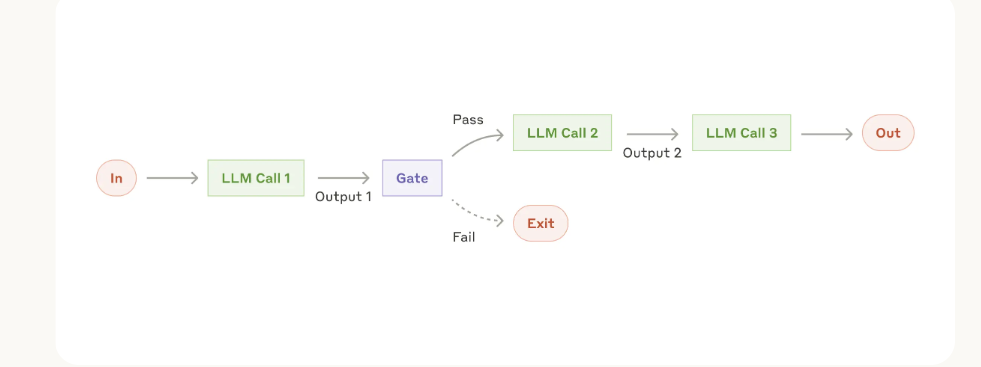

So here we are actually starting with the first workflow, which is prompt chaining. Essentially, in the prompt chaining, what we are doing is that we can decompose a task into the sequential subtasks and then we call the LLM where at each step, output of the LLM become the input of the next step.

In [12]:
from concurrent.futures import ThreadPoolExecutor
from typing import List, Dict, Callable


def prompt_chaining(input_text: str, prompts: List[str]) -> str:
    """
    Execute a sequence of LLM calls where each step's output 
    becomes the next step's input.
    
    Args:
        input_text: Initial text to process
        prompts: List of prompts/instructions for each step
    
    Returns:
        Final processed text after all steps
    """
    current_text = input_text
    
    for step, prompt in enumerate(prompts, 1):
        print(f"\nStep {step}:")
        
        # Combine the prompt with current text
        full_prompt = f"{prompt}\nInput: {current_text}"
        
        # Process through LLM
        current_text = llm_call(full_prompt)
        print(current_text)
    
    return current_text

Essentially what this court is doing is just a "for loop" where the inputs become the prompt to the LLM, and the outputs become the new prompt to the new LLM call. So It's a chaining the input and output together. 

### Example: Workflow 1: Prompt Chaining

In [13]:
data_processing_steps = [
    """Extract only the numerical values and their associated metrics from the text.
    Format each as 'value: metric' on a new line.
    Example format:
    92: customer satisfaction
    45%: revenue growth""",
    
    """Convert all numerical values to percentages where possible.
    If not a percentage or points, convert to decimal (e.g., 92 points -> 92%).
    Keep one number per line.
    Example format:
    92%: customer satisfaction
    45%: revenue growth""",
    
    """Sort all lines in descending order by numerical value.
    Keep the format 'value: metric' on each line.
    Example:
    92%: customer satisfaction
    87%: employee satisfaction""",
    
    """Format the sorted data as a markdown table with columns:
    | Metric | Value |
    |:--|--:|
    | Customer Satisfaction | 92% |"""
]


report = """
Q3 Performance Summary:
Our customer satisfaction score rose to 92 points this quarter.
Revenue grew by 45% compared to last year.
Market share is now at 23% in our primary market.
Customer churn decreased to 5% from 8%.
New user acquisition cost is $43 per user.report
Product adoption rate increased to 78%.
Employee satisfaction is at 87 points.
Operating margin improved to 34%.
"""

final_output = prompt_chaining(input_text=report, prompts=data_processing_steps)


Step 1:
Here are the numerical values and their associated metrics:

92: customer satisfaction score
45%: revenue growth
23%: market share
5%: customer churn
43: new user acquisition cost
78%: product adoption rate
87: employee satisfaction
34%: operating margin
8%: customer churn (previous quarter)

Step 2:
Here is the converted list in the desired format:

92%: customer satisfaction score
45%: revenue growth
23%: market share
5%: customer churn
43: new user acquisition cost (cannot be converted to percentage or decimal)
78%: product adoption rate
87%: employee satisfaction
34%: operating margin
8%: customer churn (previous quarter)

Step 3:
Here is the sorted list in descending order by numerical value:

92%: customer satisfaction score
87%: employee satisfaction
78%: product adoption rate
45%: revenue growth
43: new user acquisition cost (cannot be converted to percentage or decimal)
34%: operating margin
23%: market share
8%: customer churn (previous quarter)
5%: customer churn

S

So there in the above example as the result gets print out and every step you can look at the step by step where the flow of the things are going. And that's so nice because as we say being transparent and simple is a quite useful when we work with this workflows. 

I can print out just the final outcome of the example to get the final answer as well. 

In [14]:
print("The final outcome after processing the report through the prompt chain is:")
print("-----------------------------------------------------------")
print(final_output)

The final outcome after processing the report through the prompt chain is:
-----------------------------------------------------------
Here is the formatted markdown table:

| Metric | Value |
|:--|--:|
| Customer Satisfaction | 92% |
| Employee Satisfaction | 87% |
| Product Adoption Rate | 78% |
| Revenue Growth | 45% |
| Operating Margin | 34% |
| Market Share | 23% |
| Customer Churn (previous quarter) | 8% |
| Customer Churn | 5% |
| New User Acquisition Cost | 43 |

Let me know if you need any further assistance!


## Workflow 2: Parallelization

In parallelization, the goal is to work simultaneously on tasks. To achieve this, we can decompose a task into subtasks and run them in parallel using the LLM. The benefit of dividing a task into subtasks is that it increase speed and the ability to perform multiple runs at the same time. This is another efficient way of working.

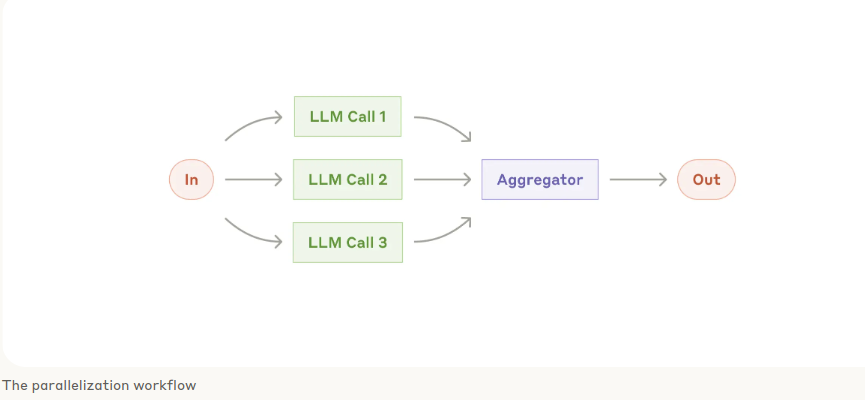

We can write it's main python codm in function named ```parallel```, where it takes two input , first is "prompt" and the second is inputs, and the inputs is the "Python list" of the prompts that we want to run in parallel.

In [15]:
def parallel(prompt: str, inputs: List[str], n_workers: int = 3) -> List[str]:
    """Process multiple inputs concurrently with the same prompt."""
    with ThreadPoolExecutor(max_workers=n_workers) as executor:
        futures = [executor.submit(llm_call, f"{prompt}\nInput: {x}") for x in inputs]
        return [f.result() for f in futures]

### Example: Workflow 2: Parallelization

In [16]:
stakeholders = [
    """Customers:
    - Price sensitive
    - Want better tech
    - Environmental concerns""",
    
    """Employees:
    - Job security worries
    - Need new skills
    - Want clear direction""",
    
    """Investors:
    - Expect growth
    - Want cost control
    - Risk concerns""",
    
    """Suppliers:
    - Capacity constraints
    - Price pressures
    - Tech transitions"""
]

impact_results = parallel(
    """Analyze how market changes will impact this stakeholder group.
    Provide specific impacts and recommended actions.
    Format with clear sections and priorities.""",
    stakeholders
)

print("Analysis Results for Each Stakeholder Group:")
print("=" * 50)

for i, result in enumerate(impact_results, 1):
    print(f"\nStakeholder Group {i}:")
    print("-" * 50)
    #warpped_result = textwrap.fill(result, width=80)
    #print(warpped_result)
    print(result)
    print("=" * 50)

Analysis Results for Each Stakeholder Group:

Stakeholder Group 1:
--------------------------------------------------
**Market Change Impact Analysis: Customers**

**Section 1: Market Changes Affecting Customers**

* Rising costs and inflation
* Advancements in technology and digitalization
* Increasing awareness and regulations related to environmental sustainability

**Section 2: Impacts on Customers**

**Priority 1: Price Sensitivity**

* Impact: Decreased purchasing power due to rising costs and inflation
* Effect: Customers may seek cheaper alternatives or reduce overall spending
* Recommended Action:
	+ Offer affordable pricing options or loyalty programs to maintain customer loyalty
	+ Explore cost-saving measures without compromising product quality

**Priority 2: Desire for Better Technology**

* Impact: Increased demand for innovative and eco-friendly products
* Effect: Customers may switch to competitors offering more advanced technology
* Recommended Action:
	+ Invest in re

## Workflow 3: Routing

So now this workflow is about routing. Routing is a process where the LLM call router receives an input and, depending on the input, makes a decision on which specialized LLM call to perform. This is useful for handling distinct categories of inputs. For example, if you have an input relevant to one topic, the router can direct it to the appropriate LLM call specialized for that topic. This ensures that each input is handled by the most suitable LLM, improving the efficiency and accuracy of the responses.

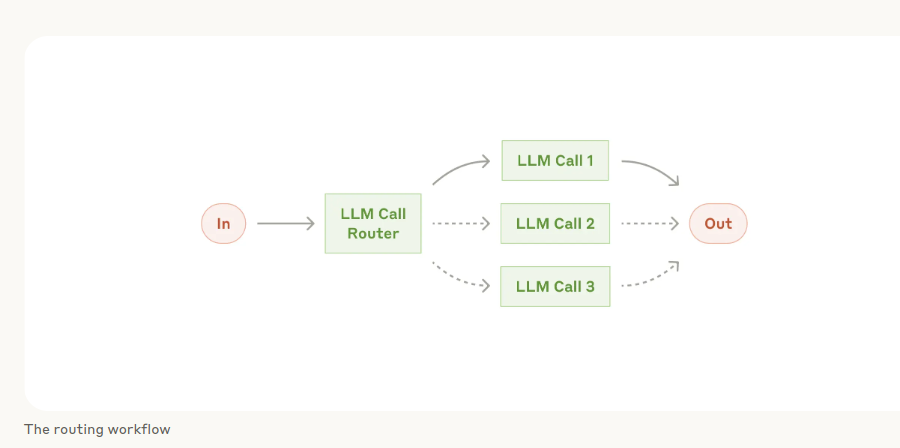

The function ```routing``` is defined in the code block below. The function takes an **input string** and a **dictionary of routes**. It uses a LLM to analyze the input and decide which route (or support team) is most appropriate. The function first creates a prompt that asks the LLM to explain its reasoning and select a route. It then calls the LLM with this prompt and extracts the reasoning and selected route from the LLM's response. Finally, it uses the selected route to process the input with a specialized prompt and returns the result.


In [17]:
def routing(input: str, routes: Dict[str, str]) -> str:
    
    """Route input to specialized prompt using content classification."""
    # First determine appropriate route using LLM with chain-of-thought
    print(f"\nAvailable routes: {list(routes.keys())}")
    selector_prompt = f"""
    Analyze the input and select the most appropriate support team from these 
    options: {list(routes.keys())}
    First explain your reasoning, then provide your selection in this XML format:

    <reasoning>
    Brief explanation of why this ticket should be routed to a specific team.
    Consider key terms, user intent, and urgency level.
    </reasoning>

    <selection>
    The chosen team name
    </selection>

    Input: {input}""".strip()
    
    route_response = llm_call(selector_prompt)
    reasoning = extract_xml(route_response, 'reasoning')
    route_key = extract_xml(route_response, 'selection').strip().lower()
    
    print("Routing Analysis:")
    print(reasoning)
    print(f"\nSelected route: {route_key}")
    
    # Process input with selected specialized prompt
    selected_prompt = routes[route_key]
    return llm_call(f"{selected_prompt}\nInput: {input}")

### Example: Workflow 3: Routing

In [18]:
support_routes = {
    "billing": """You are a billing support specialist. Follow these guidelines:
    1. Always start with "Billing Support Response:"
    2. First acknowledge the specific billing issue
    3. Explain any charges or discrepancies clearly
    4. List concrete next steps with timeline
    5. End with payment options if relevant
    
    Keep responses professional but friendly.
    
    Input: """,
    
    "technical": """You are a technical support engineer. Follow these guidelines:
    1. Always start with "Technical Support Response:"
    2. List exact steps to resolve the issue
    3. Include system requirements if relevant
    4. Provide workarounds for common problems
    5. End with escalation path if needed
    
    Use clear, numbered steps and technical details.
    
    Input: """,
    
    "account": """You are an account security specialist. Follow these guidelines:
    1. Always start with "Account Support Response:"
    2. Prioritize account security and verification
    3. Provide clear steps for account recovery/changes
    4. Include security tips and warnings
    5. Set clear expectations for resolution time
    
    Maintain a serious, security-focused tone.
    
    Input: """,
    
    "product": """You are a product specialist. Follow these guidelines:
    1. Always start with "Product Support Response:"
    2. Focus on feature education and best practices
    3. Include specific examples of usage
    4. Link to relevant documentation sections
    5. Suggest related features that might help
    
    Be educational and encouraging in tone.
    
    Input: """
}

# Test with different support tickets
tickets = [
    """Subject: Can't access my account
    Message: Hi, I've been trying to log in for the past hour but keep 
    getting an 'invalid password' error. 
    I'm sure I'm using the right password. Can you help me regain access? 
    This is urgent as I need to 
    submit a report by end of day.
    - John""",
    
    """Subject: Unexpected charge on my card
    Message: Hello, I just noticed a charge of $49.99 on my credit card from 
    your company, but I thought
    I was on the $29.99 plan. Can you explain this charge and adjust 
    it if it's a mistake?
    Thanks,
    Sarah""",
    
    """Subject: How to export data?
    Message: I need to export all my project data to Excel. 
    I've looked through the docs but can't
    figure out how to do a bulk export. Is this possible? 
    If so, could you walk me through the steps?
    Best regards,
    Mike"""
]

print("Processing support tickets...\n")
for i, ticket in enumerate(tickets, 1):
    print(f"\nTicket {i}:")
    print("-" * 40)
    print(ticket)
    print("\nResponse:")
    print("-" * 40)
    response = routing(ticket, support_routes)
    print(response)

Processing support tickets...


Ticket 1:
----------------------------------------
Subject: Can't access my account
    Message: Hi, I've been trying to log in for the past hour but keep 
    getting an 'invalid password' error. 
    I'm sure I'm using the right password. Can you help me regain access? 
    This is urgent as I need to 
    submit a report by end of day.
    - John

Response:
----------------------------------------

Available routes: ['billing', 'technical', 'account', 'product']
Routing Analysis:
The user is experiencing a technical issue with account access, and the urgency level is high due to a time-sensitive deadline.

Selected route: technical
Technical Support Response:

Dear John,

I apologize for the inconvenience you're experiencing with accessing your account. I'm happy to help you resolve the issue as quickly as possible.

**Step 1: Password Reset**

To rule out any password-related issues, let's try resetting your password. Please follow these steps:

1. G

## Workflow 4: Evaluator-Optimizer

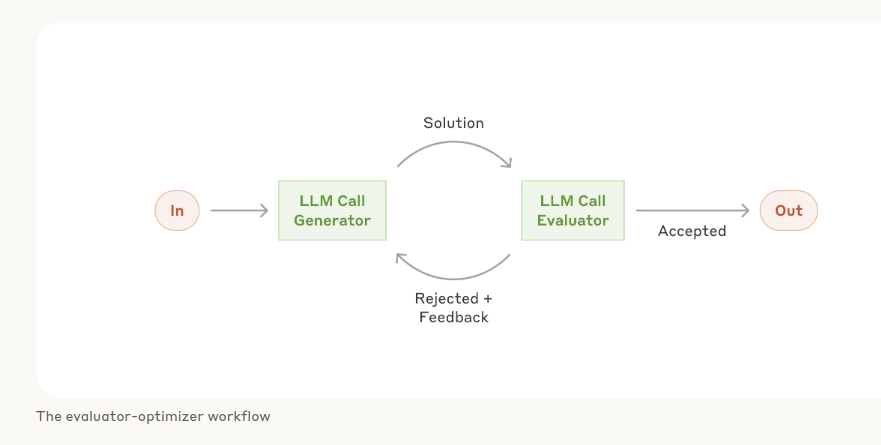

So here we are working with the Evaluator-Optimizer workflow, which is simply a workflow where one LLM call generates a response while another provides the evaluation and feedback in a loop. When to use this workflow is very interesting because this workflow is very effective when we have two things. The first is clear evaluation criteria, and the second is that you can get value from iterative refinement. These two signs of a good fit are:

1. The LLM response can be demonstrably improved when feedback is provided.
2. The LLM can provide meaningful feedback.

So, in a sense this workflow work well for tasks that can be improved, and you have meaningful feedback too.

In [19]:
from typing import Tuple, Dict, List

def generate(prompt: str, task: str, context: str = "") -> Tuple[str, str]:
    
    """Generate and improve a solution based on feedback."""
    full_prompt = f"{prompt}\n{context}\nTask: {task}" if context else f"{prompt}\nTask: {task}"
    response = llm_call(full_prompt)
    thoughts = extract_xml(response, "thoughts")
    result = extract_xml(response, "response")
    
    print("\n=== GENERATION START ===")
    print(f"Thoughts:\n{thoughts}\n")
    print(f"Generated:\n{result}")
    print("=== GENERATION END ===\n")
    
    return thoughts, result

def evaluate(prompt: str, content: str, task: str) -> Tuple[str, str]:
    """Evaluate if a solution meets requirements."""
    full_prompt = f"{prompt}\nOriginal task: {task}\nContent to evaluate: {content}"
    response = llm_call(full_prompt)
    evaluation = extract_xml(response, "evaluation")
    feedback = extract_xml(response, "feedback")
    
    print("=== EVALUATION START ===")
    print(f"Status: {evaluation}")
    print(f"Feedback: {feedback}")
    print("=== EVALUATION END ===\n")
    
    return evaluation, feedback


def eval_optimizer(task: str, evaluator_prompt: str, generator_prompt: 
                   str) -> Tuple[str, List[Dict[str, str]]]:
    """Keep generating and evaluating until requirements are met."""
    memory = []
    chain_of_thought = []
    
    thoughts, result = generate(generator_prompt, task)
    memory.append(result)
    chain_of_thought.append({"thoughts": thoughts, "result": result})
        
    improvement_count = 0
    
    while True:
        evaluation, feedback = evaluate(evaluator_prompt, result, task)
        if evaluation == "PASS":
            return result, chain_of_thought
        
        if evaluation == "NEEDS_IMPROVEMENT":
            improvement_count += 1
        if improvement_count >= 2:
            print("Too many improvements needed. Stopping the process.")
            return result, chain_of_thought
        
        context = "\n".join([
            "Previous attempts:",
            *[f"- {m}" for m in memory],
            f"\nFeedback: {feedback}"
        ])
        
        thoughts, result = generate(generator_prompt, task, context)
        memory.append(result)
        chain_of_thought.append({"thoughts": thoughts, "result": result})


### Example: Workflow 4: Evaluator-Optimizer

Here the example we are working on is a coding exercise (compute the full covariance of matrix). The coding exercise involves generating code and evaluating it based on **time complexity** and **software engineering best practices**. The evaluator  will assess the code and provide feedback, indicating whether it passes, fails, or needs improvement. If the code needs improvement, the feedback is passed to the generator function which then generates a new version of the code considering the feedback.

In [20]:
evaluator_prompt = """
Evaluate this following code implementation for:

1.time complexity
2.software engineering best practices


You should be evaluating only and not attemping to solve the task.
Only output "PASS" if all criteria are met and you have 
no further suggestions for improvements.
Output your evaluation concisely in the following format.

<evaluation>PASS, NEEDS_IMPROVEMENT, or FAIL</evaluation>
<feedback>
What needs improvement and why.
</feedback>
"""

generator_prompt = """
Your goal is to complete the task based on <user input>. 
If there are feedback 
from your previous generations, you should 
reflect on them to improve your solution

Output your answer concisely in the following format: 

<thoughts>••••••••••••••••••
[Your understanding of the task and feedback and 
how you plan to improve]
</thoughts>

<response>
[Your code implementation here]
</response>
"""

task = """
<user input>
Suppose you have a dataset with n rows (samples) and p columns (features). 
You want to compute the full covariance (or correlation) matrix of these p features. 
Write me Python code this matrix and state the time 
complexity in Big-O notation with respect to n and p. You can not use any external 
libraries for this task.
</user input>
"""

eval_optimizer(task, evaluator_prompt, generator_prompt)


=== GENERATION START ===
Thoughts:
•••••••••••••••••
I understand that the task is to write a Python code to compute the full covariance (or correlation) matrix of p features from a dataset with n samples, without using any external libraries. This is a fundamental problem in statistics and machine learning. To improve my solution, I will focus on implementing an efficient algorithm to compute the covariance matrix and analyze its time complexity.

From the feedback, I assume that I need to provide a clear and concise solution with a proper understanding of the task and its complexity.


Generated:

Here is the Python code to compute the covariance matrix:
```
def compute_covariance_matrix(data):
    n = len(data)
    p = len(data[0])
    mean_vector = [sum(x) / n for x in zip(*data)]
    covariance_matrix = [[0 for _ in range(p)] for _ in range(p)]
    
    for i in range(p):
        for j in range(p):
            for k in range(n):
                covariance_matrix[i][j] += (data[k]

('\n```\ndef compute_mean_vector(feature_values):\n    """\n    Computes the mean vector of the feature values.\n    \n    Args:\n        feature_values (list of lists): A list of lists, where each inner list represents a feature.\n        \n    Returns:\n        list: The mean vector of the feature values.\n    """\n    num_samples = len(feature_values)\n    num_features = len(feature_values[0])\n    mean_vector = [sum(x) / num_samples for x in zip(*feature_values)]\n    return mean_vector\n\n\ndef compute_covariance_matrix(feature_values):\n    """\n    Computes the covariance matrix of the feature values.\n    \n    Args:\n        feature_values (list of lists): A list of lists, where each inner list represents a feature.\n        \n    Returns:\n        list of lists: The covariance matrix of the feature values.\n    """\n    num_samples = len(feature_values)\n    num_features = len(feature_values[0])\n    \n    # Compute the mean vector\n    mean_vector = compute_mean_vector(featu